# 14. Model Training - LSTM + Transformer

## Objective
Train leakage-safe sequence models (LSTM and Transformer) using the **same feature set and time split as Step-13**, compare against RF/XGB baselines, and analyze regime-aware behavior.

## 1) Imports & Config

In [1]:
from pathlib import Path
from typing import Dict, List, Tuple
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 250)
pd.set_option('display.width', 220)

RANDOM_STATE = 42
TRAIN_START = pd.Timestamp('2023-04-18')
TRAIN_END = pd.Timestamp('2024-12-31')
TEST_START = pd.Timestamp('2025-01-01')
TEST_END = pd.Timestamp('2025-12-30')

SEQUENCE_WINDOW = 20
EXPECTED_TRAIN_SEQ_SHAPE = (37813, 20, 163)
EXPECTED_TEST_SEQ_SHAPE = (21888, 20, 163)

BATCH_SIZE = 64
EPOCHS = 12
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 3

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 2) Load Dataset + Step-13-Consistent Feature/Split Logic

In [2]:
def resolve_input_path() -> Path:
    """Resolve final modeling dataset path across notebook/repo execution contexts."""
    candidates = [
        Path('..') / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet',
        Path('Market_Data') / 'processed' / 'final_model_dataset_with_volatility.parquet',
        Path('ml_pipeline') / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet',
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError('final_model_dataset_with_volatility.parquet not found.')


def load_data(path: Path) -> pd.DataFrame:
    """Load parquet and enforce deterministic time-series order."""
    data = pd.read_parquet(path)
    data['Date'] = pd.to_datetime(data['Date'], errors='raise')
    data['Ticker'] = data['Ticker'].astype(str)
    data = data.sort_values(['Ticker', 'Date']).reset_index(drop=True)
    return data


def select_features(data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, List[str]]:
    """Use same feature selection contract as Step-13 baselines."""
    assert 'target' in data.columns, 'target column is missing.'
    drop_cols = ['Date', 'Ticker', 'target', 'volatility_regime_label', 'vol_cluster_regime_name']
    feature_cols = [c for c in data.columns if c not in drop_cols]

    X = data[feature_cols].copy()
    y = data['target'].astype(int).copy()

    non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
    assert not non_numeric, f'Non-numeric feature columns found: {non_numeric}'
    assert X.isna().sum().sum() == 0, 'NaNs detected in selected features.'
    return X, y, feature_cols


def split_data(
    data: pd.DataFrame,
    X: pd.DataFrame,
    y: pd.Series,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.DataFrame, pd.DataFrame]:
    """Create strict time-based split identical to Step-13."""
    train_mask = (data['Date'] >= TRAIN_START) & (data['Date'] <= TRAIN_END)
    test_mask = (data['Date'] >= TEST_START) & (data['Date'] <= TEST_END)

    X_train = X.loc[train_mask].copy()
    y_train = y.loc[train_mask].copy()
    X_test = X.loc[test_mask].copy()
    y_test = y.loc[test_mask].copy()

    df_train = data.loc[train_mask].copy()
    df_test = data.loc[test_mask].copy()

    assert len(X_train) > 0 and len(X_test) > 0, 'Train/Test split produced empty dataset.'
    assert df_train['Date'].max() < df_test['Date'].min(), 'Train/Test temporal overlap detected.'
    assert df_train.sort_values(['Ticker', 'Date']).index.equals(df_train.index), 'Train order changed unexpectedly.'
    assert df_test.sort_values(['Ticker', 'Date']).index.equals(df_test.index), 'Test order changed unexpectedly.'
    return X_train, X_test, y_train, y_test, df_train, df_test


input_path = resolve_input_path()
df = load_data(input_path)
X_all, y_all, feature_columns = select_features(df)
X_train, X_test, y_train, y_test, df_train, df_test = split_data(df, X_all, y_all)

print(f'Input path: {input_path}')
print(f'Dataset shape: {df.shape}')
print(f'Feature count: {len(feature_columns)}')
print(f'Train shape: {X_train.shape} | Test shape: {X_test.shape}')

Input path: C:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\processed\final_model_dataset_with_volatility.parquet
Dataset shape: (63541, 168)
Feature count: 163
Train shape: (39733, 163) | Test shape: (23808, 163)


## 3) Data Scaling (Train-Only Fit) + Sequence Construction

In [3]:
def get_regime_column(data: pd.DataFrame) -> str:
    """Resolve available regime label column for analysis."""
    if 'volatility_regime_label' in data.columns:
        return 'volatility_regime_label'
    if 'vol_cluster_regime_name' in data.columns:
        return 'vol_cluster_regime_name'
    raise AssertionError('No regime label column found.')


REGIME_COL = get_regime_column(df)


def scale_features_train_only(
    X_train_part: pd.DataFrame,
    X_test_part: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame, StandardScaler]:
    """Fit StandardScaler on training features only, then transform train/test."""
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_part),
        columns=X_train_part.columns,
        index=X_train_part.index,
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_part),
        columns=X_test_part.columns,
        index=X_test_part.index,
    )
    return X_train_scaled, X_test_scaled, scaler


def create_sequences_with_meta(
    df_part: pd.DataFrame,
    X_scaled_part: pd.DataFrame,
    y_part: pd.Series,
    feature_cols: List[str],
    regime_col: str,
    window: int = 20,
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Create fixed-length per-ticker sequences and aligned metadata."""
    seq_X: List[np.ndarray] = []
    seq_y: List[int] = []
    meta_records: List[Dict[str, object]] = []

    temp = df_part[['Ticker', 'Date', regime_col]].copy()
    temp[feature_cols] = X_scaled_part[feature_cols]
    temp['target'] = y_part.values
    temp = temp.sort_values(['Ticker', 'Date']).reset_index(drop=True)

    for ticker, grp in temp.groupby('Ticker', sort=False):
        values = grp[feature_cols].to_numpy(dtype=np.float32)
        labels = grp['target'].to_numpy(dtype=np.int64)
        dates = grp['Date'].to_numpy()
        regimes = grp[regime_col].astype(str).to_numpy()
        if len(grp) <= window:
            continue

        for i in range(window, len(grp)):
            seq_X.append(values[i - window:i])
            seq_y.append(labels[i])
            meta_records.append(
                {
                    'Ticker': ticker,
                    'Date': pd.Timestamp(dates[i]),
                    'regime_raw': regimes[i],
                }
            )

    X_seq = np.asarray(seq_X, dtype=np.float32)
    y_seq = np.asarray(seq_y, dtype=np.float32)
    meta_df = pd.DataFrame(meta_records)
    return X_seq, y_seq, meta_df


X_train_scaled, X_test_scaled, scaler = scale_features_train_only(X_train, X_test)

X_seq_train, y_seq_train, meta_train = create_sequences_with_meta(
    df_train, X_train_scaled, y_train, feature_columns, REGIME_COL, window=SEQUENCE_WINDOW
)
X_seq_test, y_seq_test, meta_test = create_sequences_with_meta(
    df_test, X_test_scaled, y_test, feature_columns, REGIME_COL, window=SEQUENCE_WINDOW
)

assert X_seq_train.ndim == 3 and X_seq_test.ndim == 3, 'Sequence arrays must be 3D.'
assert X_seq_train.shape[1] == SEQUENCE_WINDOW and X_seq_test.shape[1] == SEQUENCE_WINDOW, 'Sequence window mismatch.'
assert X_seq_train.shape[2] == len(feature_columns), 'Feature dimension mismatch in sequences.'

assert X_seq_train.shape == EXPECTED_TRAIN_SEQ_SHAPE, f'Unexpected train sequence shape: {X_seq_train.shape}'
assert X_seq_test.shape == EXPECTED_TEST_SEQ_SHAPE, f'Unexpected test sequence shape: {X_seq_test.shape}'

print(f'X_seq_train: {X_seq_train.shape} | y_seq_train: {y_seq_train.shape}')
print(f'X_seq_test: {X_seq_test.shape} | y_seq_test: {y_seq_test.shape}')
display(meta_test.head(3))

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_20152\957377778.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  temp[feature_cols] = X_scaled_part[feature_cols]
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_20152\957377778.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  temp[feature_cols] = X_scaled_part[feature_cols]
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_20152\957377778.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

X_seq_train: (37813, 20, 163) | y_seq_train: (37813,)
X_seq_test: (21888, 20, 163) | y_seq_test: (21888,)


,Ticker,Date,regime_raw
0,ABB,2025-01-29,HIGH
1,ABB,2025-01-30,HIGH
2,ABB,2025-01-31,HIGH


## 4) Train/Validation Split for Monitoring (Time-Based, No Shuffle)

In [4]:
def split_train_validation_by_time(
    X_seq: np.ndarray,
    y_seq: np.ndarray,
    meta_seq: pd.DataFrame,
    val_frac: float = 0.15,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, pd.DataFrame, pd.DataFrame]:
    """Split train-sequences into train/val using date cutoff (no randomization)."""
    assert 0 < val_frac < 0.5, 'val_frac should be between 0 and 0.5.'
    unique_dates = np.array(sorted(meta_seq['Date'].unique()))
    cutoff_idx = int(len(unique_dates) * (1 - val_frac))
    cutoff_idx = min(max(cutoff_idx, 1), len(unique_dates) - 1)
    cutoff_date = pd.Timestamp(unique_dates[cutoff_idx])

    train_mask = meta_seq['Date'] < cutoff_date
    val_mask = meta_seq['Date'] >= cutoff_date

    X_tr = X_seq[train_mask.values]
    y_tr = y_seq[train_mask.values]
    X_val = X_seq[val_mask.values]
    y_val = y_seq[val_mask.values]
    meta_tr = meta_seq.loc[train_mask].reset_index(drop=True)
    meta_val = meta_seq.loc[val_mask].reset_index(drop=True)

    assert len(X_tr) > 0 and len(X_val) > 0, 'Train/validation split produced empty subset.'
    assert meta_tr['Date'].max() < meta_val['Date'].min(), 'Temporal overlap detected between train and validation.'
    return X_tr, y_tr, X_val, y_val, meta_tr, meta_val


X_seq_tr, y_seq_tr, X_seq_val, y_seq_val, meta_tr, meta_val = split_train_validation_by_time(
    X_seq_train, y_seq_train, meta_train, val_frac=0.15
)

train_ds = TensorDataset(torch.from_numpy(X_seq_tr), torch.from_numpy(y_seq_tr))
val_ds = TensorDataset(torch.from_numpy(X_seq_val), torch.from_numpy(y_seq_val))
test_ds = TensorDataset(torch.from_numpy(X_seq_test), torch.from_numpy(y_seq_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train sequences (fit): {X_seq_tr.shape}')
print(f'Validation sequences: {X_seq_val.shape}')
print(f'Test sequences: {X_seq_test.shape}')

Train sequences (fit): (31970, 20, 163)
Validation sequences: (5843, 20, 163)
Test sequences: (21888, 20, 163)


## 5) Deep Learning Model Definitions (LSTM + Transformer)

In [5]:
class LSTMClassifier(nn.Module):
    """Binary classifier with stacked LSTM backbone."""

    def __init__(
        self,
        input_size: int,
        hidden_size: int = 64,
        num_layers: int = 2,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        logits = self.head(self.dropout(last_hidden)).squeeze(-1)
        return logits


class PositionalEncoding(nn.Module):
    """Learnable positional encoding for fixed-length sequences."""

    def __init__(self, d_model: int, max_len: int) -> None:
        super().__init__()
        self.pe = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.normal_(self.pe, mean=0.0, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1), :]


class TransformerClassifier(nn.Module):
    """Transformer encoder based binary classifier."""

    def __init__(
        self,
        input_size: int,
        d_model: int = 64,
        n_heads: int = 4,
        num_layers: int = 2,
        dropout: float = 0.2,
        max_len: int = 20,
    ) -> None:
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model=d_model, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dropout=dropout,
            batch_first=True,
            dim_feedforward=d_model * 4,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.input_proj(x)
        h = self.pos_enc(h)
        h = self.encoder(h)
        pooled = h.mean(dim=1)
        logits = self.head(self.dropout(pooled)).squeeze(-1)
        return logits


def build_lstm(input_size: int) -> nn.Module:
    """Factory for LSTM model with required architecture defaults."""
    return LSTMClassifier(input_size=input_size, hidden_size=64, num_layers=2, dropout=0.2)


def build_transformer(input_size: int) -> nn.Module:
    """Factory for Transformer model with required architecture defaults."""
    return TransformerClassifier(
        input_size=input_size,
        d_model=64,
        n_heads=4,
        num_layers=2,
        dropout=0.2,
        max_len=SEQUENCE_WINDOW,
    )


lstm_model = build_lstm(input_size=X_seq_train.shape[2]).to(DEVICE)
transformer_model = build_transformer(input_size=X_seq_train.shape[2]).to(DEVICE)
print(lstm_model)
print(transformer_model)

LSTMClassifier(
  (lstm): LSTM(163, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (head): Linear(in_features=64, out_features=1, bias=True)
)
TransformerClassifier(
  (input_proj): Linear(in_features=163, out_features=64, bias=True)
  (pos_enc): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
    

## 6) Training + Evaluation Utilities

In [6]:
def safe_roc_auc(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """Compute ROC-AUC safely when only one class is present."""
    if len(np.unique(y_true)) < 2:
        return float('nan')
    return float(roc_auc_score(y_true, y_prob))


def classification_metrics(y_true: np.ndarray, y_prob: np.ndarray, model_name: str) -> Dict[str, float]:
    """Compute standard binary classification metrics from probabilities."""
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'Model': model_name,
        'Accuracy': float(accuracy_score(y_true, y_pred)),
        'Precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'Recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'F1': float(f1_score(y_true, y_pred, zero_division=0)),
        'ROC_AUC': safe_roc_auc(y_true, y_prob),
    }


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    device: torch.device,
) -> Tuple[float, np.ndarray, np.ndarray]:
    """Run one train/eval epoch and return loss + predictions."""
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_probs: List[np.ndarray] = []
    all_true: List[np.ndarray] = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_true.append(yb.detach().cpu().numpy())

    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_true)
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, y_true, y_prob


def train_model(
    model: nn.Module,
    train_loader_part: DataLoader,
    val_loader_part: DataLoader,
    model_name: str,
    lr: float = LEARNING_RATE,
    epochs: int = EPOCHS,
    patience: int = EARLY_STOPPING_PATIENCE,
    device: torch.device = DEVICE,
) -> Tuple[nn.Module, Dict[str, List[float]], float]:
    """Train model with validation monitoring and early stopping."""
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history: Dict[str, List[float]] = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'train_auc': [],
        'val_auc': [],
    }

    best_state: Dict[str, torch.Tensor] = {}
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_true, tr_prob = run_epoch(model, train_loader_part, criterion, optimizer, device)
        val_loss, val_true, val_prob = run_epoch(model, val_loader_part, criterion, None, device)

        tr_metrics = classification_metrics(tr_true, tr_prob, model_name)
        val_metrics = classification_metrics(val_true, val_prob, model_name)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_metrics['Accuracy'])
        history['val_acc'].append(val_metrics['Accuracy'])
        history['train_auc'].append(tr_metrics['ROC_AUC'])
        history['val_auc'].append(val_metrics['ROC_AUC'])

        print(
            f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
            f"train_loss={tr_loss:.4f} val_loss={val_loss:.4f} "
            f"train_acc={tr_metrics['Accuracy']:.4f} val_acc={val_metrics['Accuracy']:.4f} "
            f"train_auc={tr_metrics['ROC_AUC']:.4f} val_auc={val_metrics['ROC_AUC']:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'[{model_name}] Early stopping triggered at epoch {epoch}.')
                break

    assert best_state, f'{model_name} training failed to produce best state.'
    model.load_state_dict(best_state)
    return model, history, best_val_loss


@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, device: torch.device = DEVICE) -> np.ndarray:
    """Predict probabilities for positive class."""
    model.eval()
    probs: List[np.ndarray] = []
    for xb, _ in loader:
        xb = xb.to(device)
        logits = model(xb)
        probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs)


def evaluate_model(model: nn.Module, loader: DataLoader, y_true: np.ndarray, model_name: str) -> Tuple[Dict[str, float], pd.DataFrame]:
    """Evaluate model on provided loader and return metrics + confusion matrix."""
    y_prob = predict_proba(model, loader)
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = classification_metrics(y_true, y_prob, model_name=model_name)
    cm = confusion_matrix(y_true.astype(int), y_pred)
    cm_df = pd.DataFrame(cm, index=['Actual_0', 'Actual_1'], columns=['Pred_0', 'Pred_1'])
    return metrics, cm_df

## 7) Train LSTM and Transformer

In [7]:
lstm_model = build_lstm(input_size=X_seq_train.shape[2]).to(DEVICE)
transformer_model = build_transformer(input_size=X_seq_train.shape[2]).to(DEVICE)

lstm_model, lstm_history, lstm_best_val_loss = train_model(
    lstm_model,
    train_loader,
    val_loader,
    model_name='LSTM',
)

transformer_model, transformer_history, transformer_best_val_loss = train_model(
    transformer_model,
    train_loader,
    val_loader,
    model_name='Transformer',
)

print(f'LSTM best val loss: {lstm_best_val_loss:.4f}')
print(f'Transformer best val loss: {transformer_best_val_loss:.4f}')

[LSTM] Epoch 01/12 | train_loss=0.6812 val_loss=0.6996 train_acc=0.5624 val_acc=0.5218 train_auc=0.5760 val_auc=0.5306
[LSTM] Epoch 02/12 | train_loss=0.6430 val_loss=0.7155 train_acc=0.6269 val_acc=0.5179 train_auc=0.6724 val_auc=0.5314
[LSTM] Epoch 03/12 | train_loss=0.6225 val_loss=0.7439 train_acc=0.6503 val_acc=0.5003 train_auc=0.7051 val_auc=0.5120
[LSTM] Epoch 04/12 | train_loss=0.6083 val_loss=0.7393 train_acc=0.6628 val_acc=0.5163 train_auc=0.7243 val_auc=0.5250
[LSTM] Early stopping triggered at epoch 4.
[Transformer] Epoch 01/12 | train_loss=0.6970 val_loss=0.6938 train_acc=0.5184 val_acc=0.4917 train_auc=0.5099 val_auc=0.5121
[Transformer] Epoch 02/12 | train_loss=0.6910 val_loss=0.6940 train_acc=0.5297 val_acc=0.5080 train_auc=0.5235 val_auc=0.5127
[Transformer] Epoch 03/12 | train_loss=0.6879 val_loss=0.6972 train_acc=0.5393 val_acc=0.5027 train_auc=0.5478 val_auc=0.4970
[Transformer] Epoch 04/12 | train_loss=0.6819 val_loss=0.7066 train_acc=0.5591 val_acc=0.5309 train_au

## 8) Evaluation on Test Set

In [8]:
lstm_metrics, lstm_cm = evaluate_model(lstm_model, test_loader, y_seq_test, 'LSTM')
transformer_metrics, transformer_cm = evaluate_model(transformer_model, test_loader, y_seq_test, 'Transformer')

print('LSTM confusion matrix')
display(lstm_cm)
print('Transformer confusion matrix')
display(transformer_cm)

dl_metrics_df = pd.DataFrame([lstm_metrics, transformer_metrics]).set_index('Model').round(4)
display(dl_metrics_df)

LSTM confusion matrix


,Pred_0,Pred_1
Actual_0,6726,4188
Actual_1,6619,4355


Transformer confusion matrix


,Pred_0,Pred_1
Actual_0,4529,6385
Actual_1,4367,6607


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
LSTM,0.5063,0.5098,0.3968,0.4463,0.5121
Transformer,0.5088,0.5085,0.6021,0.5514,0.5123


## 9) Compare with Baseline Models (RF/XGB from Step-13)

In [9]:
def resolve_artifact_dir() -> Path:
    """Resolve model artifact path (same style as Step-13)."""
    candidates = [Path('..') / 'models', Path('models'), Path('ml_pipeline') / 'models']
    return candidates[0]


artifact_dir = resolve_artifact_dir()
artifact_dir.mkdir(parents=True, exist_ok=True)

baseline_path = artifact_dir / 'baseline_metrics_summary.json'
if baseline_path.exists():
    baseline_metrics = json.loads(baseline_path.read_text(encoding='utf-8'))
else:
    baseline_metrics = {}

rows = []
for key in ['RandomForest', 'XGBoost']:
    if key in baseline_metrics:
        row = {'Model': 'RF' if key == 'RandomForest' else 'XGB'}
        row.update({k: float(v) for k, v in baseline_metrics[key].items()})
        rows.append(row)

rows.extend([
    {'Model': 'LSTM', **{k: v for k, v in lstm_metrics.items() if k != 'Model'}},
    {'Model': 'Transformer', **{k: v for k, v in transformer_metrics.items() if k != 'Model'}},
])

comparison_df = pd.DataFrame(rows).set_index('Model')
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].round(4)
display(comparison_df)

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
RF,0.5052,0.5033,0.4326,0.4653,0.5071
XGB,0.4995,0.4969,0.4635,0.4796,0.5058
LSTM,0.5063,0.5098,0.3968,0.4463,0.5121
Transformer,0.5088,0.5085,0.6021,0.5514,0.5123


## 10) Regime-Based Analysis (LOW / MEDIUM / HIGH)

,Model,Regime,Samples,Accuracy,Precision,Recall,F1,ROC_AUC,Error_Rate
0,LSTM,HIGH,5201,0.5311,0.5622,0.4353,0.4907,0.5438,0.4689
1,LSTM,LOW,11375,0.4934,0.4811,0.3869,0.4289,0.4917,0.5066
2,LSTM,MEDIUM,5312,0.5096,0.5197,0.3788,0.4382,0.5203,0.4904
3,Transformer,HIGH,5201,0.5143,0.5224,0.7473,0.6149,0.5176,0.4857
4,Transformer,LOW,11375,0.5094,0.5011,0.5105,0.5057,0.5126,0.4906
5,Transformer,MEDIUM,5312,0.5021,0.5054,0.6469,0.5675,0.5004,0.4979


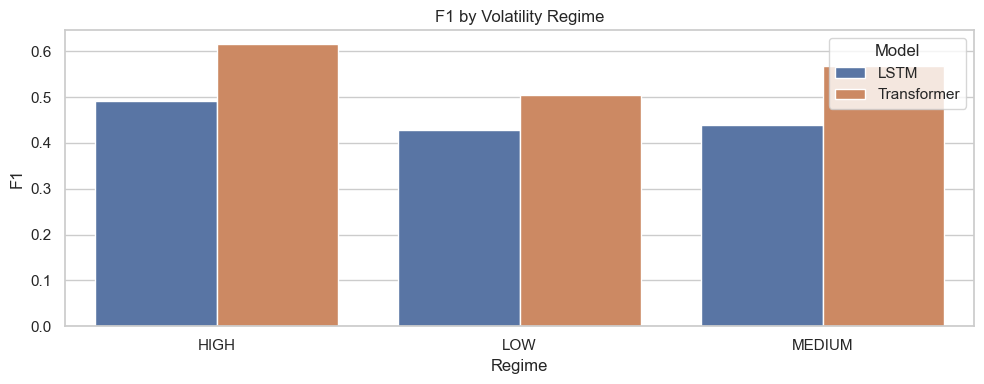

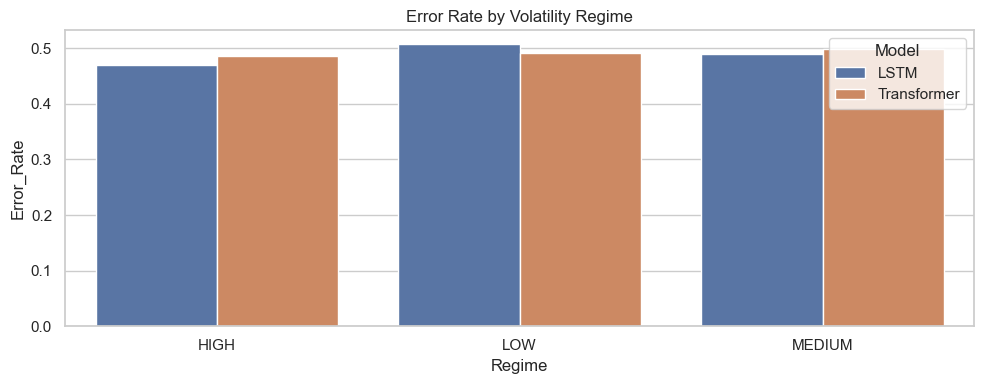

In [10]:
def normalize_regime_label(value: str) -> str:
    """Map available regime labels to LOW/MEDIUM/HIGH buckets."""
    s = str(value).upper()
    if ('LOW' in s) or ('NON' in s):
        return 'LOW'
    if ('MED' in s) or ('STABLE' in s):
        return 'MEDIUM'
    if ('HIGH' in s) or ('VOLATILE' in s):
        return 'HIGH'
    return s


def regime_metrics(y_true: np.ndarray, y_prob: np.ndarray, meta_df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    """Compute per-regime classification metrics and error counts."""
    pred_df = meta_df.copy()
    pred_df['regime'] = pred_df['regime_raw'].map(normalize_regime_label)
    pred_df['y_true'] = y_true.astype(int)
    pred_df['y_prob'] = y_prob
    pred_df['y_pred'] = (pred_df['y_prob'] >= 0.5).astype(int)
    pred_df['is_error'] = (pred_df['y_true'] != pred_df['y_pred']).astype(int)

    rows = []
    for regime, grp in pred_df.groupby('regime'):
        rows.append({
            'Model': model_name,
            'Regime': regime,
            'Samples': int(len(grp)),
            'Accuracy': accuracy_score(grp['y_true'], grp['y_pred']),
            'Precision': precision_score(grp['y_true'], grp['y_pred'], zero_division=0),
            'Recall': recall_score(grp['y_true'], grp['y_pred'], zero_division=0),
            'F1': f1_score(grp['y_true'], grp['y_pred'], zero_division=0),
            'ROC_AUC': safe_roc_auc(grp['y_true'].to_numpy(), grp['y_prob'].to_numpy()),
            'Error_Rate': float(grp['is_error'].mean()),
        })

    return pd.DataFrame(rows).sort_values(['Regime', 'Model']).reset_index(drop=True)


lstm_test_prob = predict_proba(lstm_model, test_loader)
transformer_test_prob = predict_proba(transformer_model, test_loader)

lstm_regime_df = regime_metrics(y_seq_test, lstm_test_prob, meta_test, 'LSTM')
transformer_regime_df = regime_metrics(y_seq_test, transformer_test_prob, meta_test, 'Transformer')
regime_comparison_df = pd.concat([lstm_regime_df, transformer_regime_df], ignore_index=True)
display(regime_comparison_df.round(4))

plt.figure(figsize=(10, 4))
sns.barplot(data=regime_comparison_df, x='Regime', y='F1', hue='Model')
plt.title('F1 by Volatility Regime')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=regime_comparison_df, x='Regime', y='Error_Rate', hue='Model')
plt.title('Error Rate by Volatility Regime')
plt.tight_layout()
plt.show()

## 11) Save Models + Training History + Metrics Summary

In [11]:
lstm_path = artifact_dir / 'lstm_model.pt'
transformer_path = artifact_dir / 'transformer_model.pt'
history_path = artifact_dir / 'dl_training_history.json'
metrics_path = artifact_dir / 'dl_metrics_summary.json'

torch.save(lstm_model.state_dict(), lstm_path)
torch.save(transformer_model.state_dict(), transformer_path)

history_payload = {
    'LSTM': {k: [float(x) if pd.notna(x) else None for x in v] for k, v in lstm_history.items()},
    'Transformer': {k: [float(x) if pd.notna(x) else None for x in v] for k, v in transformer_history.items()},
}
history_path.write_text(json.dumps(history_payload, indent=2), encoding='utf-8')

metrics_payload = {
    'Baseline': baseline_metrics,
    'LSTM': {k: float(v) for k, v in lstm_metrics.items() if k != 'Model'},
    'Transformer': {k: float(v) for k, v in transformer_metrics.items() if k != 'Model'},
    'Regime_Analysis': regime_comparison_df.to_dict(orient='records'),
    'Leakage_Checks': {
        'train_max_date_lt_test_min_date': bool(df_train['Date'].max() < df_test['Date'].min()),
        'train_order_preserved': bool(df_train.sort_values(['Ticker', 'Date']).index.equals(df_train.index)),
        'test_order_preserved': bool(df_test.sort_values(['Ticker', 'Date']).index.equals(df_test.index)),
        'scaler_fit_only_on_train': True,
        'sequence_window': SEQUENCE_WINDOW,
    },
}
metrics_path.write_text(json.dumps(metrics_payload, indent=2), encoding='utf-8')

assert lstm_path.exists() and transformer_path.exists(), 'Model files missing.'
assert history_path.exists() and metrics_path.exists(), 'History/metrics artifacts missing.'
print(f'Artifacts saved in: {artifact_dir.resolve()}')
print([p.name for p in artifact_dir.iterdir() if p.is_file()])

Artifacts saved in: C:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\models
['baseline_feature_importance.csv', 'baseline_metrics_summary.json', 'dl_metrics_summary.json', 'dl_training_history.json', 'lstm_model.pt', 'rf_baseline.pkl', 'transformer_model.pt', 'xgb_baseline.pkl']


## 12) Training Curves + Final Summary

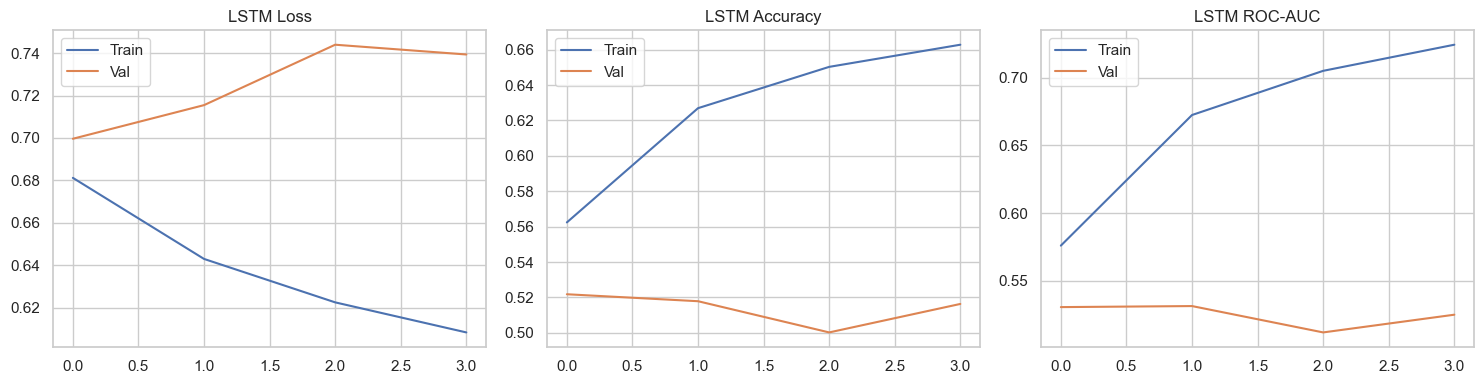

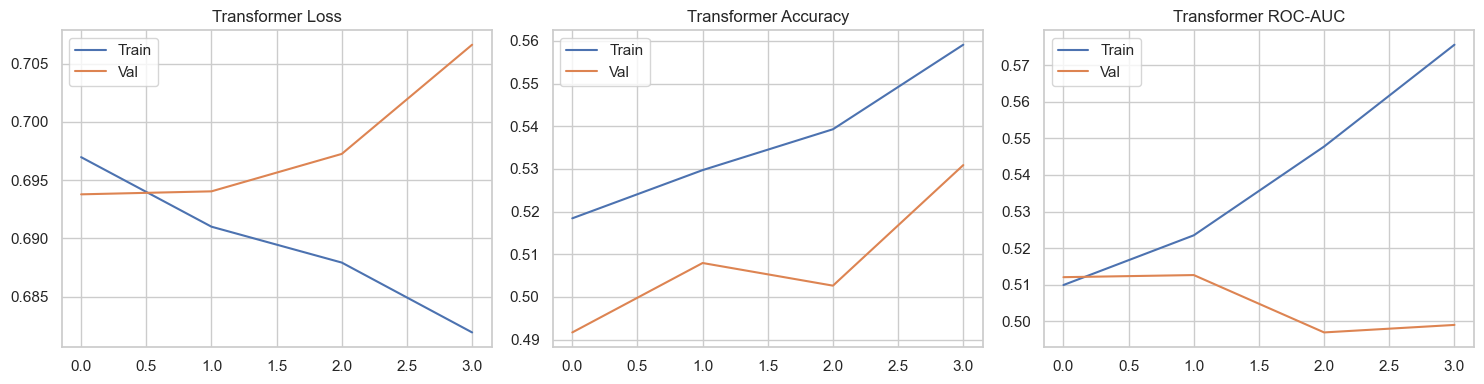

Final Summary
----------------------------------------------------------------------
Overall performance comparison:


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
RF,0.5052,0.5033,0.4326,0.4653,0.5071
XGB,0.4995,0.4969,0.4635,0.4796,0.5058
LSTM,0.5063,0.5098,0.3968,0.4463,0.5121
Transformer,0.5088,0.5085,0.6021,0.5514,0.5123


Best model by F1: Transformer
1) Sequence modeling outperforms tree baselines: True
2) Best high-volatility regime model (F1): Transformer
3) Best overall generalization model (test F1): Transformer


,check,passed
0,Train max date < Test min date,True
1,No shuffling in DataLoaders,True
2,Scaler fit only on train,True
3,Sequence window fixed at 20,True
4,Expected train sequence shape,True
5,Expected test sequence shape,True


In [12]:
def plot_history(history: Dict[str, List[float]], model_name: str) -> None:
    """Plot train/validation trajectories for core metrics."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title(f'{model_name} Loss')
    axes[0].legend()

    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'], label='Val')
    axes[1].set_title(f'{model_name} Accuracy')
    axes[1].legend()

    axes[2].plot(history['train_auc'], label='Train')
    axes[2].plot(history['val_auc'], label='Val')
    axes[2].set_title(f'{model_name} ROC-AUC')
    axes[2].legend()
    plt.tight_layout()
    plt.show()


plot_history(lstm_history, 'LSTM')
plot_history(transformer_history, 'Transformer')

if 'F1' in comparison_df.columns and not comparison_df['F1'].isna().all():
    best_model_name = comparison_df['F1'].idxmax()
else:
    best_model_name = dl_metrics_df['F1'].idxmax()

print('Final Summary')
print('-' * 70)
print('Overall performance comparison:')
display(comparison_df.round(4))
print(f'Best model by F1: {best_model_name}')

sequence_outperform_tree = False
if {'RF', 'XGB'}.issubset(comparison_df.index):
    best_tree_f1 = comparison_df.loc[['RF', 'XGB'], 'F1'].max()
    best_seq_f1 = comparison_df.loc[['LSTM', 'Transformer'], 'F1'].max()
    sequence_outperform_tree = best_seq_f1 > best_tree_f1

best_high_regime = (
    regime_comparison_df[regime_comparison_df['Regime'] == 'HIGH']
    .sort_values('F1', ascending=False)
    .head(1)
)
best_high_regime_model = best_high_regime['Model'].iloc[0] if len(best_high_regime) else 'N/A'

print(f'1) Sequence modeling outperforms tree baselines: {sequence_outperform_tree}')
print(f'2) Best high-volatility regime model (F1): {best_high_regime_model}')
print(f'3) Best overall generalization model (test F1): {best_model_name}')

leakage_checks = pd.DataFrame([
    {'check': 'Train max date < Test min date', 'passed': bool(df_train['Date'].max() < df_test['Date'].min())},
    {'check': 'No shuffling in DataLoaders', 'passed': True},
    {'check': 'Scaler fit only on train', 'passed': True},
    {'check': 'Sequence window fixed at 20', 'passed': bool(SEQUENCE_WINDOW == 20)},
    {'check': 'Expected train sequence shape', 'passed': bool(X_seq_train.shape == EXPECTED_TRAIN_SEQ_SHAPE)},
    {'check': 'Expected test sequence shape', 'passed': bool(X_seq_test.shape == EXPECTED_TEST_SEQ_SHAPE)},
])
display(leakage_checks)
assert leakage_checks['passed'].all(), 'Leakage checklist failed.'